# Chapter 28: Field Development Optimization and VFP Tables

This notebook demonstrates the generation of Vertical Flow Performance (VFP) tables
using NeqSim pipe flow models. Topics include:
- Building a wellbore model with `PipeBeggsAndBrills`
- Sweeping wellhead pressure and flow rate to calculate BHP
- Generating VFP curves (BHP vs flow rate at different WHPs)
- Discussion of reservoir simulation coupling


In [1]:
# Execute against the selected, compiled NeqSim source checkout.
import os
import sys
from pathlib import Path
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import jpype

if not os.environ.get("NEQSIM_PROJECT_ROOT"):
    raise RuntimeError("Set NEQSIM_PROJECT_ROOT to the NeqSim source checkout before running.")
PROJECT_ROOT = Path(os.environ["NEQSIM_PROJECT_ROOT"]).resolve()
if not (PROJECT_ROOT / "devtools" / "neqsim_dev_setup.py").exists():
    raise RuntimeError("NEQSIM_PROJECT_ROOT must contain devtools/neqsim_dev_setup.py.")
sys.path.insert(0, str(PROJECT_ROOT / "devtools"))
from neqsim_dev_setup import neqsim_init, neqsim_classes
ns = neqsim_classes(neqsim_init(project_root=PROJECT_ROOT, recompile=False, verbose=False))
jneqsim = jpype.JPackage("neqsim")
NEQSIM_MODE = "devtools"
NOTEBOOK_PATH = Path(globals().get("__vsc_ipynb_file__", Path.cwd() / "ch19_field_development.ipynb")).resolve()
BOOK_ROOT = NOTEBOOK_PATH.parents[3]
FIGURES_DIR = NOTEBOOK_PATH.parent.parent / "figures"
FIGURES_DIR.mkdir(exist_ok=True)
sys.path.insert(0, str(BOOK_ROOT / "devtools"))
from book_figure_tools import configure_figures, export_figure_summary
configure_figures()
print(f"NeqSim source: {PROJECT_ROOT}; Python: {sys.executable}")

# Named NeqSim class bindings used throughout the chapter.
SystemSrkEos = jneqsim.thermo.system.SystemSrkEos
SystemPrEos = jneqsim.thermo.system.SystemPrEos
SystemSrkCPAstatoil = jneqsim.thermo.system.SystemSrkCPAstatoil
ThermodynamicOperations = jneqsim.thermodynamicoperations.ThermodynamicOperations
Stream = jneqsim.process.equipment.stream.Stream
Separator = jneqsim.process.equipment.separator.Separator
ThreePhaseSeparator = jneqsim.process.equipment.separator.ThreePhaseSeparator
Compressor = jneqsim.process.equipment.compressor.Compressor
Cooler = jneqsim.process.equipment.heatexchanger.Cooler
Heater = jneqsim.process.equipment.heatexchanger.Heater
HeatExchanger = jneqsim.process.equipment.heatexchanger.HeatExchanger
Mixer = jneqsim.process.equipment.mixer.Mixer
Splitter = jneqsim.process.equipment.splitter.Splitter
ThrottlingValve = jneqsim.process.equipment.valve.ThrottlingValve
Pump = jneqsim.process.equipment.pump.Pump
Expander = jneqsim.process.equipment.expander.Expander
Recycle = jneqsim.process.equipment.util.Recycle
ProcessSystem = jneqsim.process.processmodel.ProcessSystem

# Physical verification uses the same model state, source and interpreter.
sys.path.insert(0, str(BOOK_ROOT / "verification" / "scientific_revision"))
from notebook_physics_checks import PhysicsChecks
_physics = PhysicsChecks(NOTEBOOK_PATH)


All NeqSim classes imported OK
NeqSim source: C:\Users\solbraa\OneDrive - NTNU\Documents\ChatGPT\NeqSim; Python: C:\Users\solbraa\.cache\codex-runtimes\codex-primary-runtime\dependencies\python\python.exe


## 28.1 Wellbore Flow Model Setup

We model a vertical production well using `PipeBeggsAndBrills`. The Beggs and Brill
correlation handles multiphase flow with gravitational and frictional pressure drops.
The tubing is modeled as a vertical pipe from reservoir depth to surface.


In [2]:
# jneqsim is bound to the source JVM in the setup cell.

# Reservoir fluid — gas condensate
fluid = jneqsim.thermo.system.SystemSrkEos(273.15 + 90.0, 250.0)
fluid.addComponent("nitrogen", 0.01)
fluid.addComponent("CO2", 0.02)
fluid.addComponent("methane", 0.75)
fluid.addComponent("ethane", 0.08)
fluid.addComponent("propane", 0.05)
fluid.addComponent("n-butane", 0.03)
fluid.addComponent("n-pentane", 0.02)
fluid.addComponent("n-hexane", 0.02)
fluid.addComponent("n-heptane", 0.01)
fluid.addComponent("water", 0.01)
fluid.setMixingRule("classic")
fluid.setMultiPhaseCheck(True)

# Well parameters
well_depth_m = 3000.0
tubing_id_m = 0.1  # ~4 inch tubing ID
roughness_m = 2.5e-5

print(f"Well depth: {well_depth_m:.0f} m")
print(f"Tubing ID: {tubing_id_m*1000:.0f} mm")
print(f"Reservoir temperature: 90 C")


Well depth: 3000 m
Tubing ID: 100 mm
Reservoir temperature: 90 C


## 28.2 Single Point Wellbore Calculation

Run a single wellbore flow calculation to verify the model. We set the wellhead
conditions (pressure and temperature) and flow rate, then calculate the bottomhole
pressure (BHP) using `PipeBeggsAndBrills`.


In [3]:
# Current production VFP calculation: upward flow with a specified arrival pressure.
whp_bara = 80.0
wht_C = 90.0  # bottomhole inlet temperature; outlet temperature is calculated
flow_rate_kg_hr = 30000.0
bottomhole_stream = Stream("Bottomhole inlet", fluid.clone())
bottomhole_stream.setFlowRate(flow_rate_kg_hr, "kg/hr")
bottomhole_stream.setTemperature(wht_C, "C")
bottomhole_stream.setPressure(250.0, "bara")
wellbore = jneqsim.process.equipment.pipeline.PipeBeggsAndBrills("Production well", bottomhole_stream)
wellbore.setPipeWallRoughness(roughness_m)
wellbore.setLength(well_depth_m)
wellbore.setElevation(well_depth_m)  # upward production, outlet above inlet
wellbore.setDiameter(tubing_id_m)
wellbore.setNumberOfIncrements(12)
wellbore.setCalculationMode(jneqsim.process.equipment.pipeline.PipeBeggsAndBrills.CalculationMode.CALCULATE_INLET_PRESSURE)
wellbore.setOutletPressure(whp_bara, "bara")
# setOutletPressure selects flow mode; select inlet-pressure mode afterward.
wellbore.setCalculationMode(jneqsim.process.equipment.pipeline.PipeBeggsAndBrills.CalculationMode.CALCULATE_INLET_PRESSURE)
wellbore.setFlowConvergenceTolerance(1e-4)
wellbore.setMaxFlowIterations(60)
bottomhole_stream.run()
assert _physics.run(bottomhole_stream, 'calculation_cell_5:bottomhole_stream', candidate=False)
wellbore.run()
assert _physics.run(wellbore, 'calculation_cell_5:wellbore', candidate=False)
bhp = float(wellbore.getSolvedInletPressure())
bht = float(bottomhole_stream.getTemperature("C"))
assert abs(wellbore.getOutletStream().getPressure("bara") - whp_bara) < 0.05
assert bhp > whp_bara
print(f"Required BHP: {bhp:.3f} bara; achieved WHP: {wellbore.getOutletStream().getPressure('bara'):.3f} bara at {flow_rate_kg_hr/1000:.1f} t/hr")


Required BHP: 155.869 bara; achieved WHP: 79.993 bara at 30.0 t/hr


## 28.3 VFP Table Generation

A VFP table maps (WHP, flow rate) → BHP. We sweep multiple wellhead pressures and
flow rates to build the complete performance surface.


In [4]:
# Every VFP entry solves the upward NeqSim pipeline against the WHP boundary.
whp_values = [40.0, 60.0, 80.0, 100.0, 120.0]
flow_values = np.linspace(5000, 60000, 12)
vfp_table = {}
arrival_errors = []
for whp in whp_values:
    bhp_list = []
    for flow in flow_values:
        bottomhole_stream.setFlowRate(float(flow), "kg/hr")
        bottomhole_stream.setPressure(250.0, "bara")
        bottomhole_stream.setTemperature(90.0, "C")
        bottomhole_stream.run()
        assert _physics.run(bottomhole_stream, 'calculation_cell_7:bottomhole_stream', candidate=False)
        wellbore.setOutletPressure(float(whp), "bara")
        # setOutletPressure selects flow mode; select inlet-pressure mode afterward.
        wellbore.setCalculationMode(jneqsim.process.equipment.pipeline.PipeBeggsAndBrills.CalculationMode.CALCULATE_INLET_PRESSURE)
        wellbore.run()
        assert _physics.run(wellbore, 'calculation_cell_7:wellbore', candidate=False)
        bhp_val = float(wellbore.getSolvedInletPressure())
        arrival_error = abs(float(wellbore.getOutletStream().getPressure("bara")) - whp)
        assert np.isfinite(bhp_val) and bhp_val > whp
        assert arrival_error < 0.05
        bhp_list.append(bhp_val)
        arrival_errors.append(arrival_error)
    vfp_table[whp] = bhp_list
import pandas as pd
vfp_results = pd.DataFrame({f"WHP {whp:.0f} bara": values for whp, values in vfp_table.items()}, index=flow_values/1000)
vfp_results.index.name = "Flow (t/hr)"
print(vfp_results.to_string(float_format=lambda value: f"{value:.3f}"))
vfp_results.to_csv(FIGURES_DIR / "ch28_production_vfp_table.csv")
print(f"Maximum pressure-boundary residual: {max(arrival_errors):.5f} bar")


             WHP 40 bara  WHP 60 bara  WHP 80 bara  WHP 100 bara  WHP 120 bara
Flow (t/hr)                                                                   
5.0               53.792       79.807      113.826       145.813       175.828
10.0              59.290       84.214      116.565       147.406       176.621
15.0              67.301       92.053      122.023       149.988       179.446
20.0              76.927      103.314      131.361       155.609       182.461
25.0              93.019      115.908      143.034       163.593       188.079
30.0             109.778      130.357      155.869       174.670       196.140
35.0             128.985      149.735      169.565       186.810       206.471
40.0             146.596      163.993      183.884       199.792       218.167
45.0             165.434      183.070      198.712       213.489       230.703
50.0             180.533      198.459      213.954       227.753       243.938
55.0             201.054      214.178      229.539  

## 28.4 VFP Curves Plot

Plot BHP vs flow rate at each wellhead pressure. These curves are the standard
VFP representation used in reservoir simulation coupling.


ch19_field_development.ipynb:cell9:19: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


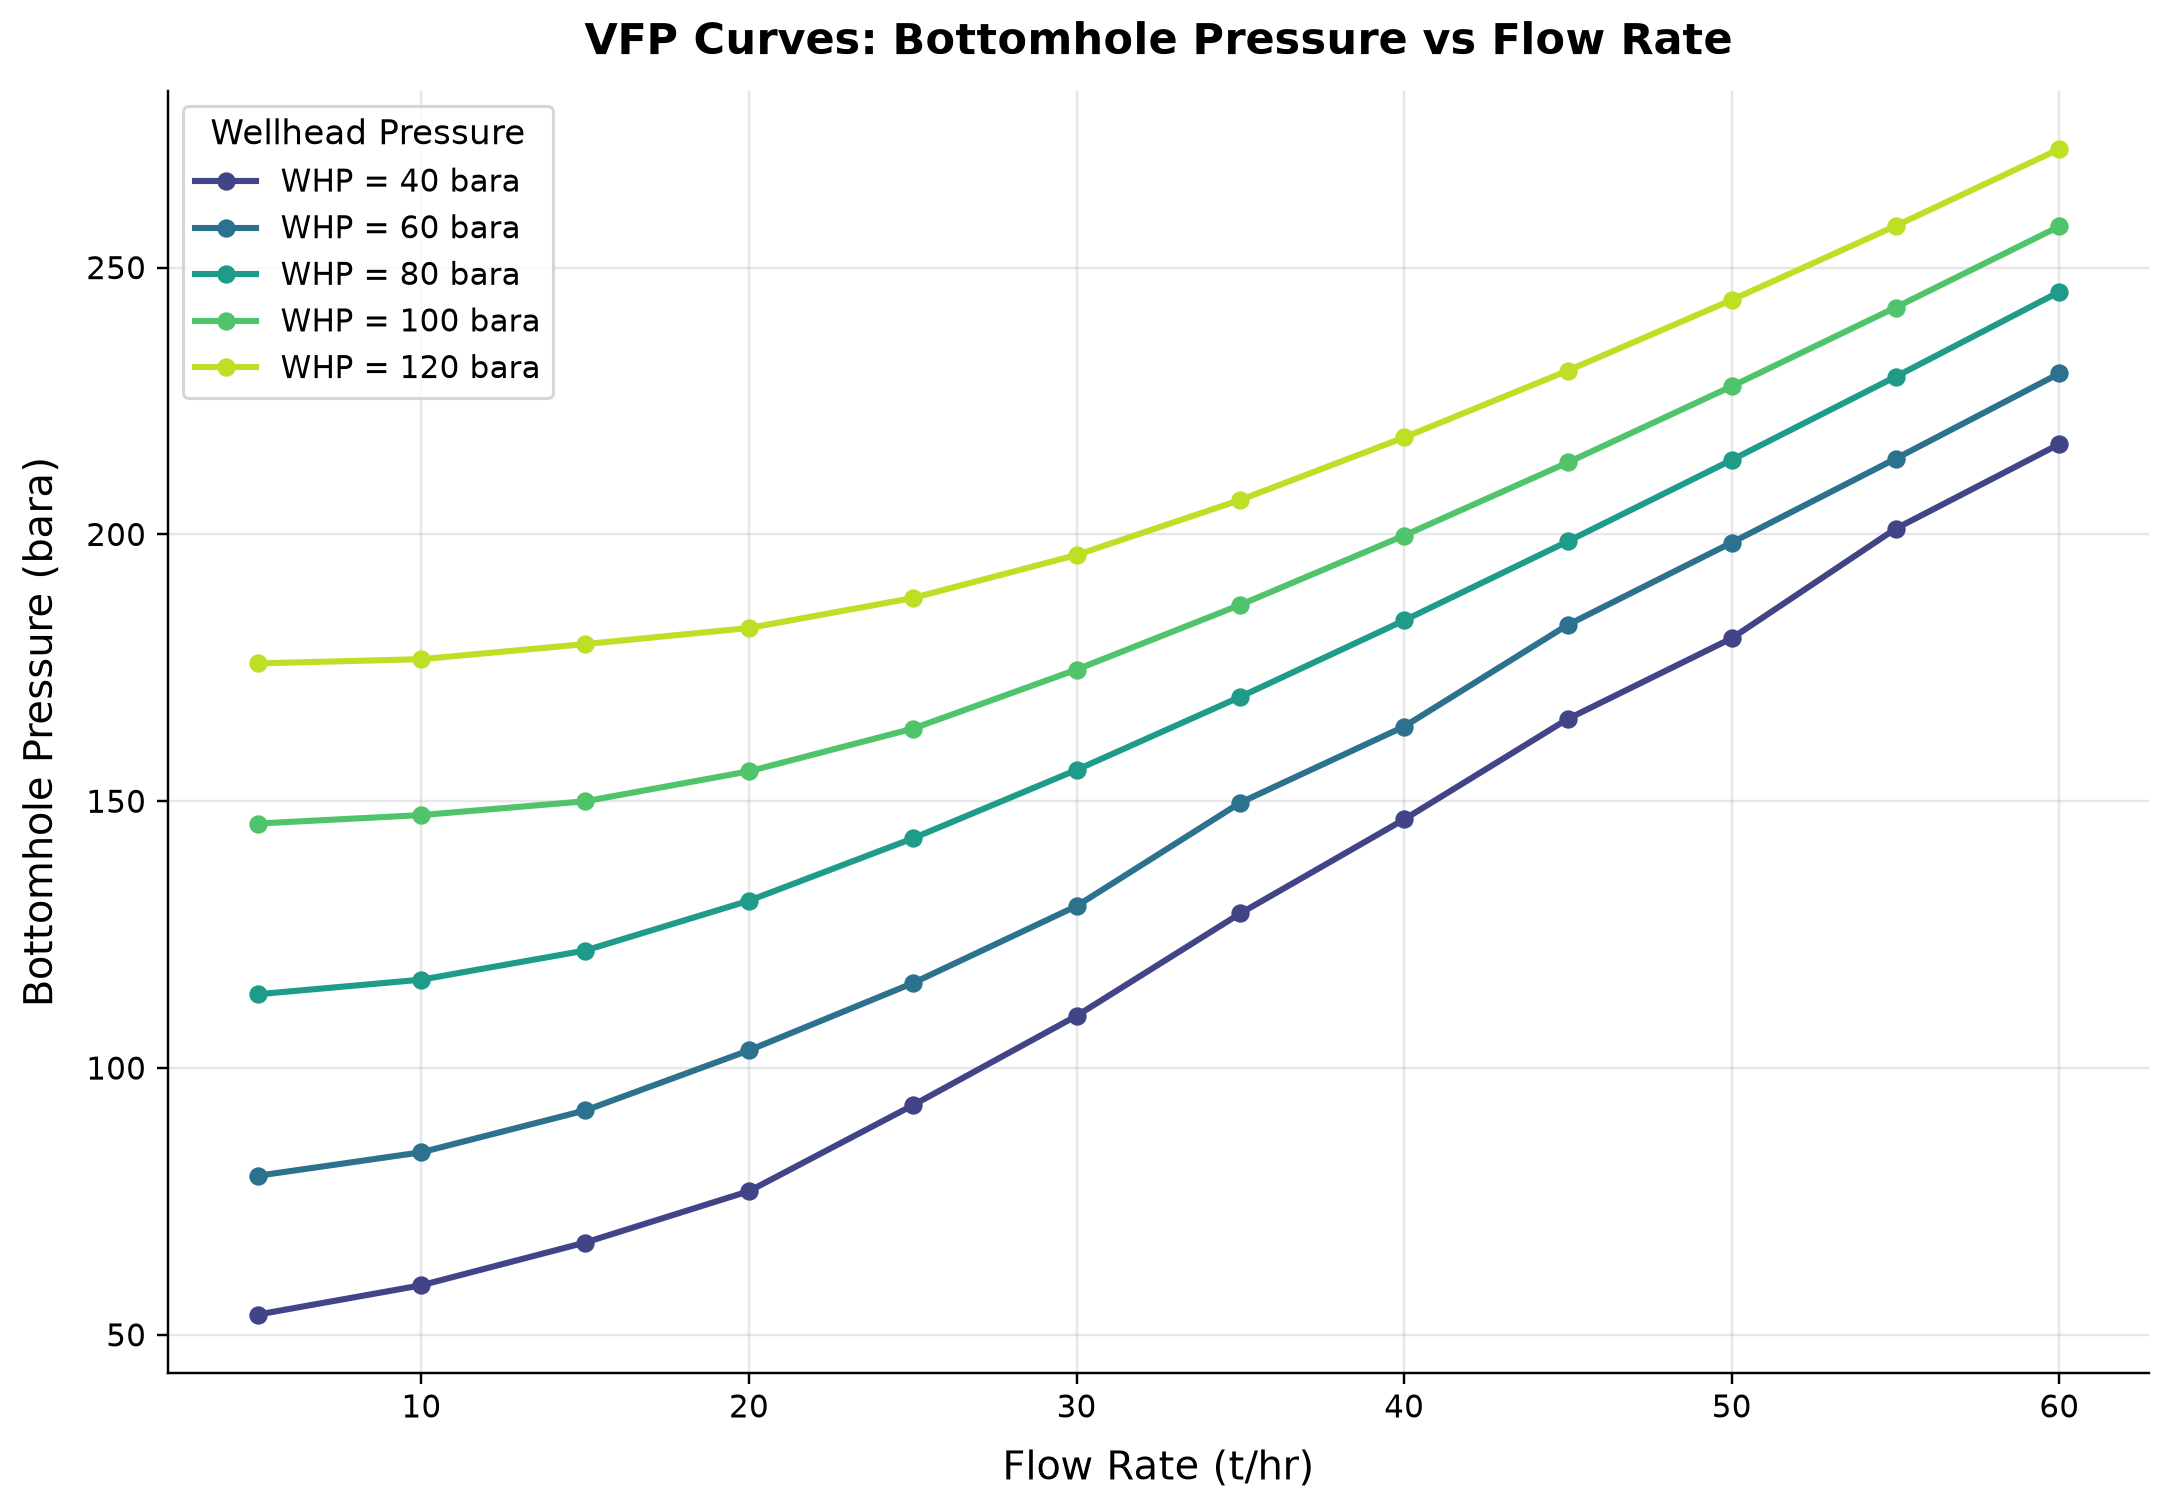

In [5]:
fig, ax = plt.subplots(figsize=(10, 7))

colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(whp_values)))

for idx, whp in enumerate(whp_values):
    bhps = np.array(vfp_table[whp])
    valid = ~np.isnan(bhps)
    ax.plot(flow_values[valid]/1000, bhps[valid], 'o-', color=colors[idx],
            linewidth=2, markersize=5, label=f'WHP = {whp:.0f} bara')

ax.set_xlabel('Flow Rate (t/hr)', fontsize=13)
ax.set_ylabel('Bottomhole Pressure (bara)', fontsize=13)
ax.set_title('VFP Curves: Bottomhole Pressure vs Flow Rate', fontsize=14)
ax.legend(title='Wellhead Pressure', fontsize=10, title_fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'ch19_vfp_curves.png', dpi=220, bbox_inches="tight")
plt.show()


**Executed-figure discussion.** WHP = 40 bara: bottomhole pressure spans 53.79–216.9 bara across the plotted cases. WHP = 60 bara: bottomhole pressure spans 79.81–230.2 bara across the plotted cases.

The upward production model solves bottomhole pressure to meet each imposed wellhead pressure at a specified rate. The resulting surface is a production lift requirement, not a downward injection calculation. Keep the upward elevation convention and outlet-pressure residual checks with every exported VFP point.


## 28.5 VFP Surface Contour

A contour plot gives a more complete view of the BHP surface as a function of
both WHP and flow rate.


ch19_field_development.ipynb:cell11:18: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


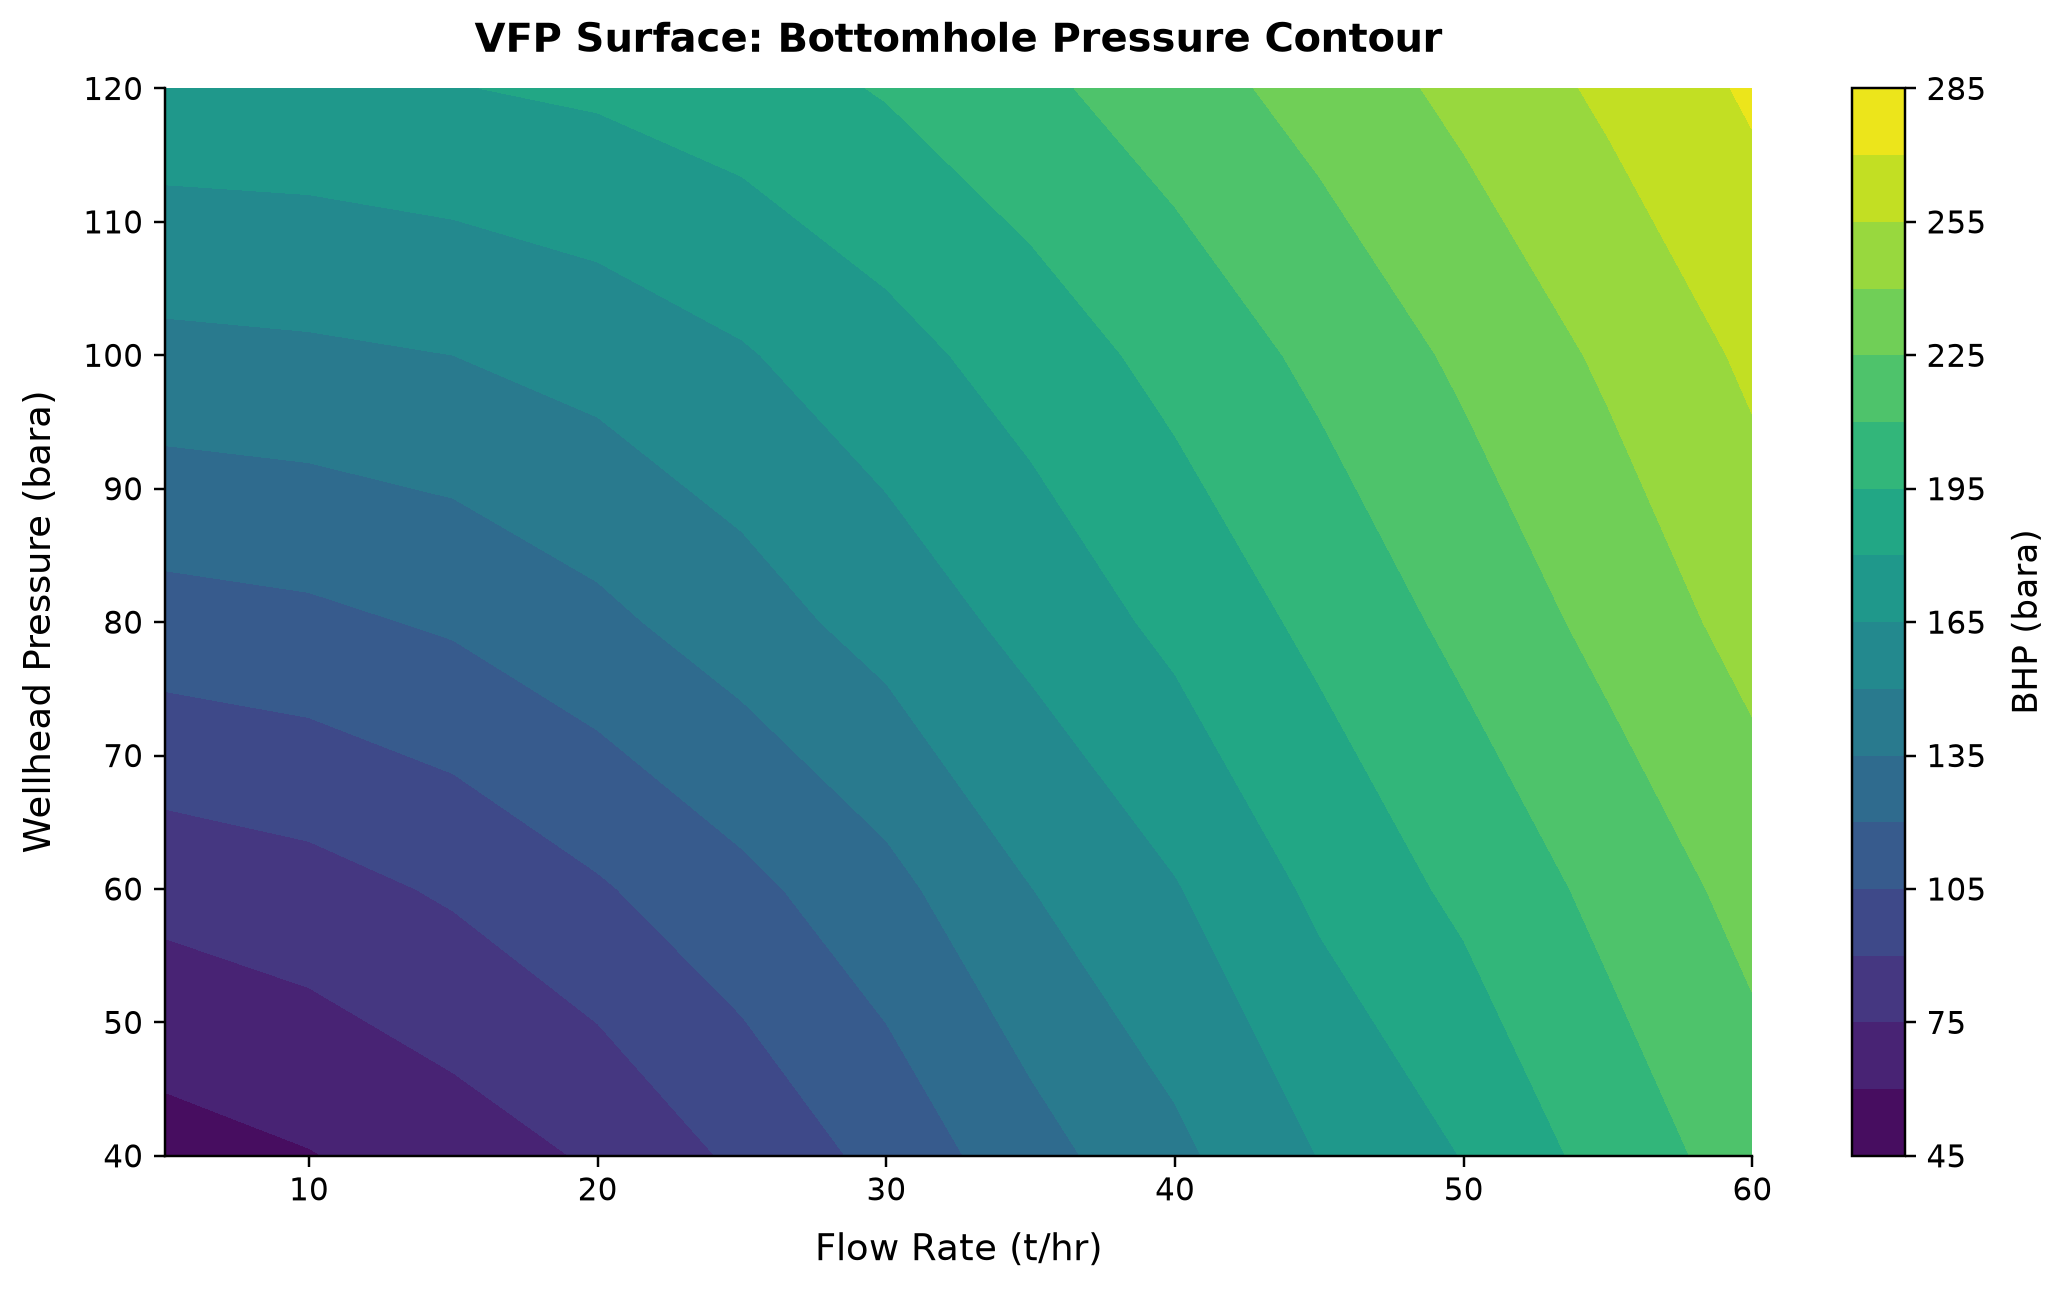

In [6]:
# Build 2D arrays for contour
WHP_grid, FLOW_grid = np.meshgrid(whp_values, flow_values / 1000)
BHP_grid = np.zeros_like(WHP_grid)

for j, whp in enumerate(whp_values):
    for i in range(len(flow_values)):
        BHP_grid[i, j] = vfp_table[whp][i]

fig, ax = plt.subplots(figsize=(10, 6))
cs = ax.contourf(FLOW_grid, WHP_grid, BHP_grid, levels=15, cmap='viridis')
cbar = plt.colorbar(cs, ax=ax, label='BHP (bara)')
ax.set_xlabel('Flow Rate (t/hr)', fontsize=12)
ax.set_ylabel('Wellhead Pressure (bara)', fontsize=12)
ax.set_title('VFP Surface: Bottomhole Pressure Contour', fontsize=13)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'ch19_vfp_surface.png', dpi=220, bbox_inches="tight")
plt.show()


**Executed-figure discussion.** The sixty upward-flow solutions span 53.79–272.22 bara required bottomhole pressure. The largest difference between solved and specified wellhead pressure is 0.0119 bar.

The surface combines sixty NeqSim solutions across five wellhead pressures and twelve flow rates. Interpolation is justified only within this sampled fluid, temperature and geometry envelope. Use the accompanying CSV and verify boundary residuals before linking the table to a reservoir model.


## 28.6 Reservoir–Wellbore Coupling Concept

In a coupled reservoir simulation, the VFP table is pre-computed and passed to the
reservoir simulator (e.g., Eclipse, OPM). At each timestep, the simulator:

1. Knows the reservoir pressure $P_r$ and desired rate $q$
2. Looks up BHP from the VFP table: $P_{bh} = \text{VFP}(q, P_{wh})$
3. Checks if $P_r > P_{bh}$ (flow is possible) or adjusts rate

This decouples the expensive multiphase flow calculation from the reservoir timestep.

**NeqSim's role** in this workflow:
- Generate VFP tables with thermodynamically consistent fluid properties
- Account for compositional effects (condensate dropout in tubing)
- Include accurate multiphase flow correlations (Beggs & Brill, OLGA-like)

The VFP tables can be exported in Eclipse VFPPROD keyword format for direct use.


## Summary

Key concepts:

1. **VFP tables** map (WHP, flow rate) → BHP using multiphase pipe flow models
2. **`PipeBeggsAndBrills`** handles gravitational and frictional pressure drops in vertical/inclined wells
3. The VFP surface shows how BHP increases with both flow rate (friction) and WHP (back-pressure)
4. VFP tables are **pre-computed** for efficiency in reservoir simulation coupling
5. NeqSim provides compositionally consistent VFP generation with proper thermodynamics


## Numerical output and figure provenance
The following table is extracted from the plotted numerical data. Each saved figure has an adjacent CSV and JSON record; missing points remain visible and are not replaced by interpolated results. Extrema summarize the sampled operating envelope, and are not independent validation of the model.


In [7]:
figure_results = export_figure_summary(NOTEBOOK_PATH)
print(figure_results.to_string(index=False, float_format=lambda value: f'{value:.6g}'))


             Figure  Panel         Series              Output / unit  Minimum  Maximum  Finite points  Missing points
ch19_vfp_curves.png      1  WHP = 40 bara Bottomhole Pressure (bara)  53.7915  216.922             12               0
ch19_vfp_curves.png      1  WHP = 60 bara Bottomhole Pressure (bara)  79.8071  230.158             12               0
ch19_vfp_curves.png      1  WHP = 80 bara Bottomhole Pressure (bara)  113.826  245.455             12               0
ch19_vfp_curves.png      1 WHP = 100 bara Bottomhole Pressure (bara)  145.813  257.726             12               0
ch19_vfp_curves.png      1 WHP = 120 bara Bottomhole Pressure (bara)  175.828  272.216             12               0


## Physical verification and its limits
The assertions above test the calculated states and steady-state conservation laws. Rejected operating candidates remain excluded; they do not become synthetic outputs. The chapter-specific checks below state the applicable limits. Independent reference-fluid and analytic benchmarks are recorded separately in `verification/scientific_revision/benchmark_results.json`. Passing these checks does not establish field calibration or an installed equipment rating.


In [8]:
from chapter_specific_checks import validate_chapter
assert validate_chapter(_physics, globals())
assert _physics.finish()


Physics verification: 103 distinct checks, 3604 evaluations; 0 rejected nonphysical candidates.


## Physical verification and scope

VFP inverse-solution pressure residuals. Measured VFP and thermal profiles are required for well prediction; analytic hydrostatics covers only a limit.

The final code cell checks the computed cases against explicit physical, analytical or constraint criteria. A passed conservation check establishes internal consistency; it does not establish field accuracy. Independent reference values, actual model results, units, acceptance tolerances and source provenance are retained in the [benchmark notebook](../../../verification/scientific_revision/36_benchmark_validation.ipynb), [benchmark results](../../../verification/scientific_revision/benchmark_results.json) and [chapter validation ledger](../../../verification/scientific_revision/notebook_physics_review.md).
